# **Opciones Americanas con CRR**
#### Paola A. Figueroa Álvarez
#### 25/abril/2026

## **Instrucciones**
- Integra el código visto en clase en un notebook y contesta las preguntas con base en lo que observas

## **Árbol binomial de Cox-Ross-Rubinstein**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # --- Árbol de precios al vencimiento ---
    # ST[i] = S0 * u^(N-i) * d^i  para i = 0, 1, ..., N
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # --- Valores de la opción al vencimiento ---
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # --- Inducción hacia atrás ---
    for step in range(N-1, -1, -1):
        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])

        # Valor de continuar (esperanza descontada)
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])

        if style == 'american':
            # Valor de ejercer ahora
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)
        else:
            V = V_continuar

    return V[0]

# Parámetros
S0    = 669.03
K     = 680
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")

Call europea  : $9.3925
Call americana: $9.3925  (prima por ejercicio anticipado: $0.0000)
Put europea   : $17.9412
Put americana : $18.2479  (prima por ejercicio anticipado: $0.3068)


### **Convergencia**

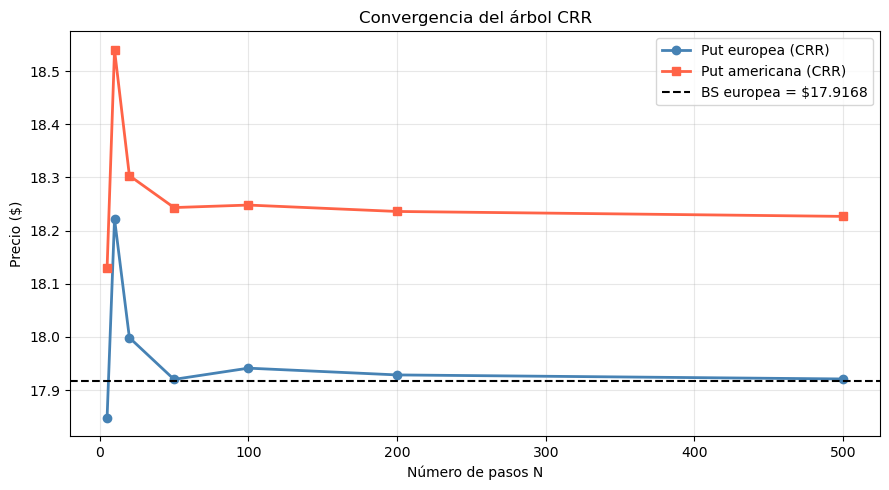

In [2]:
# Precio vs. número de pasos
pasos   = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio BS como referencia
from scipy.stats import norm
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Prima por ejercicio anticipado en función del moneyness**

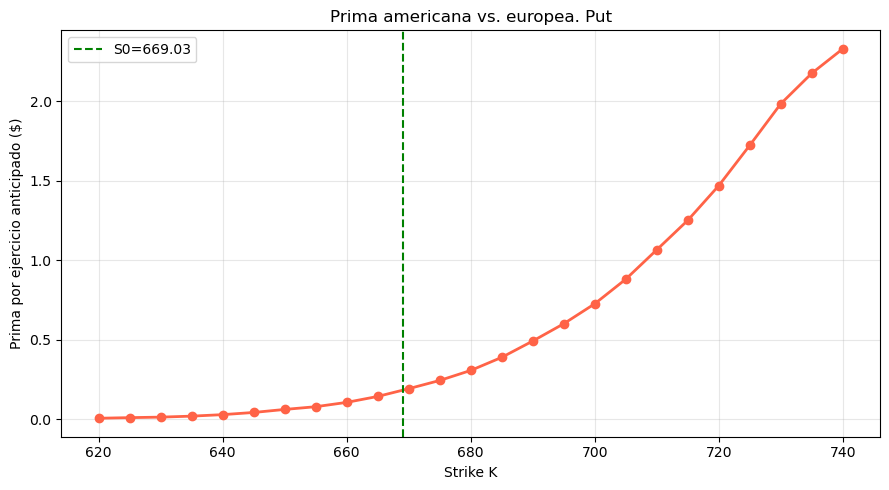

In [3]:
K_range      = np.arange(620, 741, 5)
prima_antic  = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea. Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Comparación CRR vs. Black-Scholes**

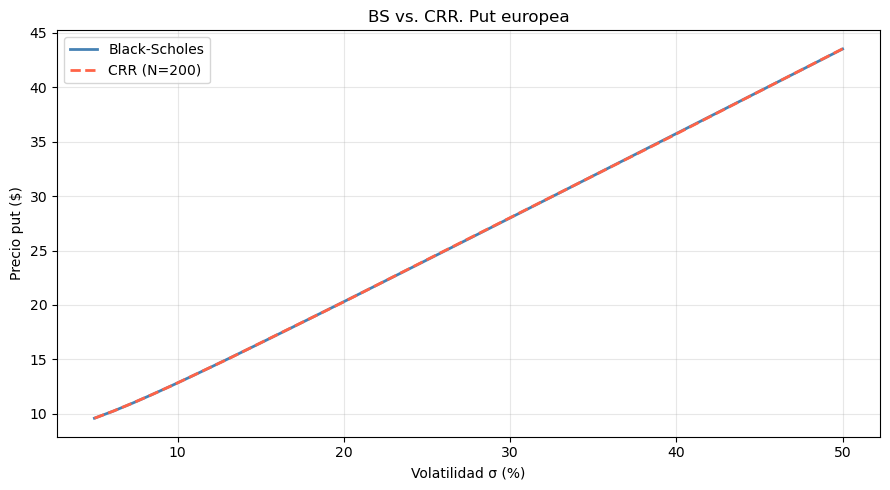

In [4]:
sigma_range  = np.linspace(0.05, 0.50, 40)
bs_precios   = []
crr_precios  = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR. Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas de reflexión

- **1.- ¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?**
    - Casi nunca conviene ejercer anticipadamente una call sin dividendos porque estarías renunciando al valor temporal y al beneficio de diferir el pago del strike (valor del dinero en el tiempo es decir, el interés que podrías ganar manteniendo el efectivo). Si hay dividendos, podrías ejercer antes para capturar el dividendo, lo que puede hacer óptimo el ejercicio anticipado.
- **2.- En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?**
    - El precio oscila porque el modelo CRR usa un árbol discreto para aproximar un proceso continuo. Dependiendo de si el número de pasos es par o impar, el árbol puede quedar desalineado con el strike, haciendo que a veces sobrevalúe y otras subvalúe la opción. A medida que N crece, estas diferencias se suavizan y el precio converge.
- **3.- La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?**
    - En una put muy ITM, el derecho de vender caro ya tiene mucho valor hoy. Si ejerces anticipadamente, recibes ese dinero de inmediato y puedes invertirlo antes, en lugar de esperar hasta el vencimiento. Por eso, cuando las tasas son positivas, el ejercicio temprano puede ser mejor.
- **4.- Si aumentas T de 31 días a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea? ¿Por qué?**
    - Cuando aumenta T crece el tiempo en el que la opción puede volverse más valiosa y también las oportunidades de ejercer anticipadamente. Esto hace que la put americana gane más valor relativo frente a la europea. En otras palabras, la flexibilidad adicional (ejercer en cualquier momento) vale más cuando hay más tiempo disponible.
- **5.- El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?**
    - Las probabilidades neutrales al riesgo no reflejan la probabilidad real de los movimientos, sino que ajustan el mundo para que todos los activos crezcan a la tasa libre de riesgo. Esto es válido porque permite hacer pricing mediante no arbitraje, descontando flujos esperados bajo esa medida.